# Exploratory Visualizations

**Dataset:** UCI Student Performance — Portuguese course
**Prepared by:** Student C
**Role:** Visualization Specialist

This notebook builds exploratory visualizations on top of the cleaned dataset
(`data/processed/cleaned_data.csv`) and the statistics already produced by
Student B (`reports/summary_statistics.csv`, `reports/normality_tests.csv`,
`reports/pearson_correlation.csv`).

Figures are saved to `reports/figures/`.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats

current_directory = Path.cwd()
project_root = (
    current_directory.parent
    if current_directory.name == "notebooks"
    else current_directory
)

data_path = project_root / "data" / "processed" / "cleaned_data.csv"
figures_dir = project_root / "reports" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(data_path)

plt.style.use("seaborn-v0_8")
sns.set_palette("husl")

numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print(f"Dataset shape: {df.shape}")
print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")

Dataset shape: (649, 33)
Numeric columns (16): ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']
Categorical columns (17): ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


/tmp/ipykernel_611/1497280513.py:27: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()


## 1. Distribution Plots

Histogram + KDE for every numeric column, with mean and median marked.
The grade columns (`G1`, `G2`, `G3`) and `absences` are the most important
to look at closely — Student A already flagged `absences` as having
outliers.

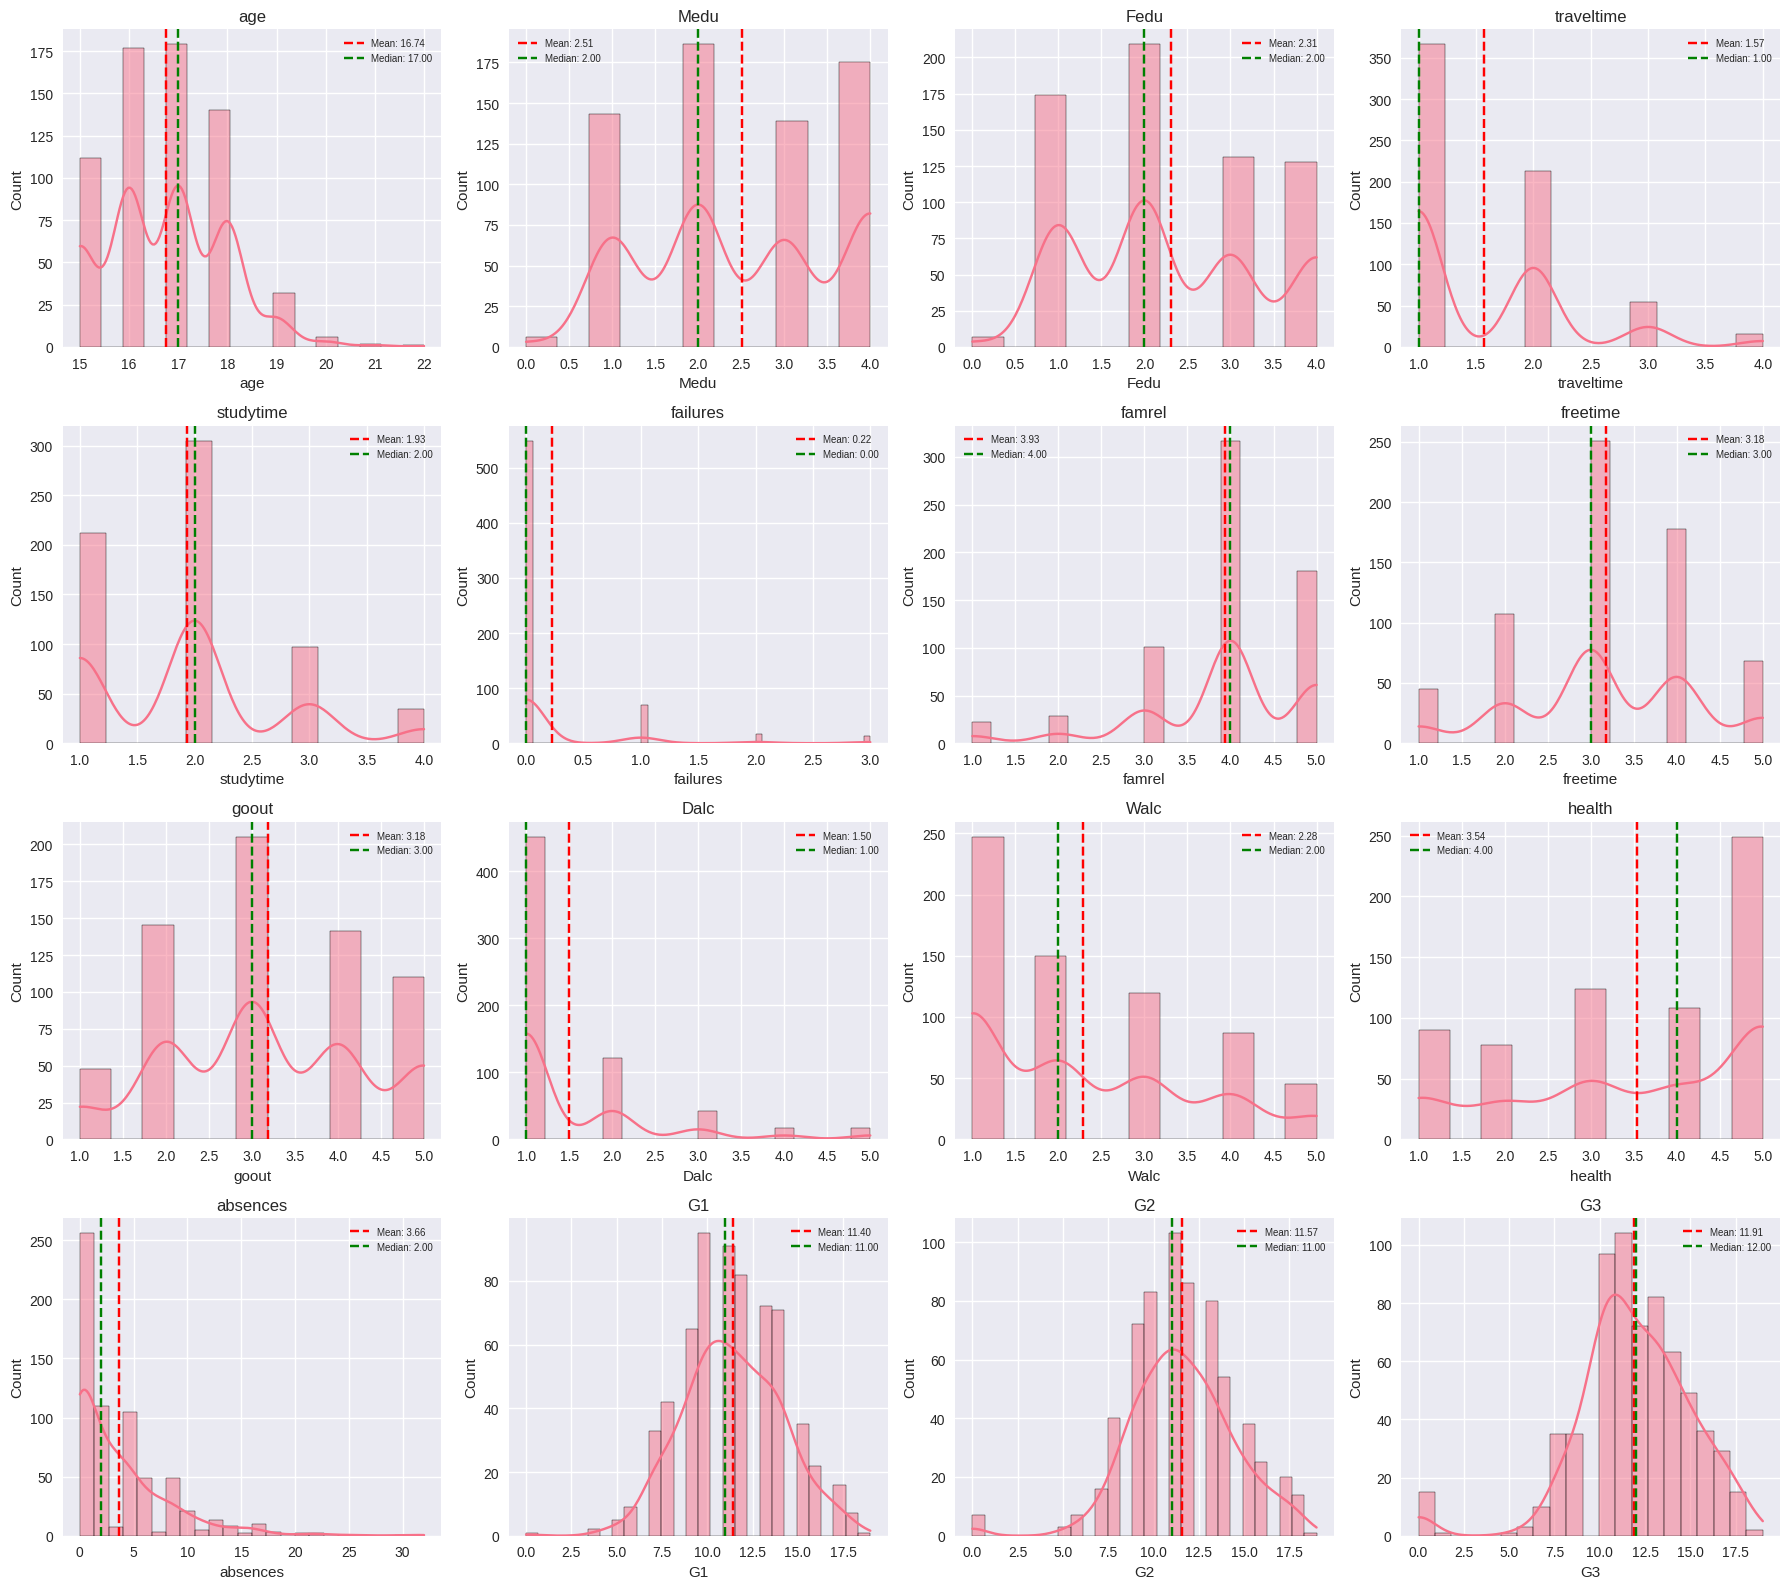

In [2]:
n_cols = 4
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    data = df[col].dropna()
    sns.histplot(data, kde=True, ax=axes[idx])
    axes[idx].set_title(col)
    axes[idx].axvline(data.mean(), color="red", linestyle="--", label=f"Mean: {data.mean():.2f}")
    axes[idx].axvline(data.median(), color="green", linestyle="--", label=f"Median: {data.median():.2f}")
    axes[idx].legend(fontsize=7)

for idx in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig(figures_dir / "distribution_plots.png", dpi=300, bbox_inches="tight")
plt.show()

## 2. Box Plots by Category

Final grade (`G3`) compared across a few categorical groupings: `sex`,
`school`, and `internet` access at home. This is a natural fit since G3
is the outcome variable most students will care about.

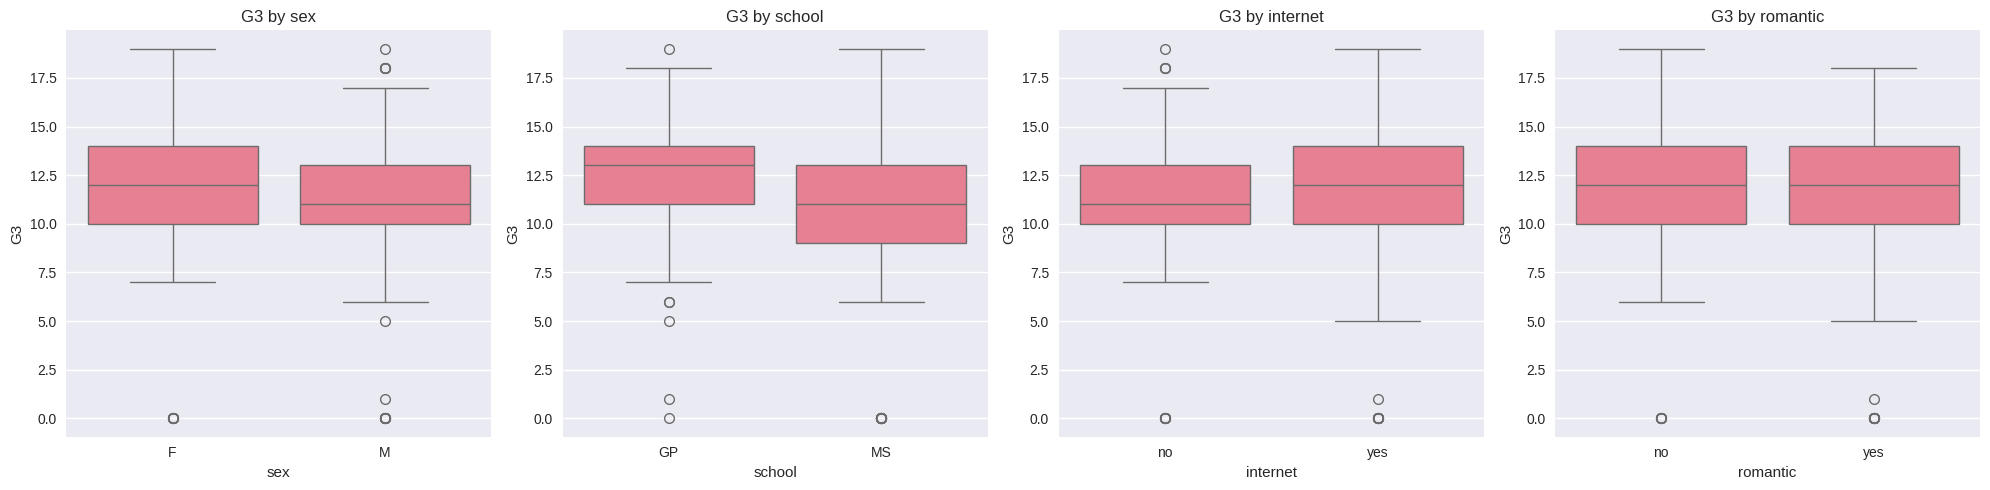

In [3]:
compare_cols = ["sex", "school", "internet", "romantic"]
compare_cols = [c for c in compare_cols if c in df.columns]

fig, axes = plt.subplots(1, len(compare_cols), figsize=(5 * len(compare_cols), 5))
if len(compare_cols) == 1:
    axes = [axes]

for idx, cat_col in enumerate(compare_cols):
    sns.boxplot(data=df, x=cat_col, y="G3", ax=axes[idx])
    axes[idx].set_title(f"G3 by {cat_col}")

plt.tight_layout()
plt.savefig(figures_dir / "boxplots.png", dpi=300, bbox_inches="tight")
plt.show()

## 3. Correlation Heatmap

Full numeric correlation matrix. `G1`, `G2`, and `G3` are expected to be
strongly correlated since they're grades from consecutive periods —
this cross-checks Student B's `pearson_correlation.csv`.

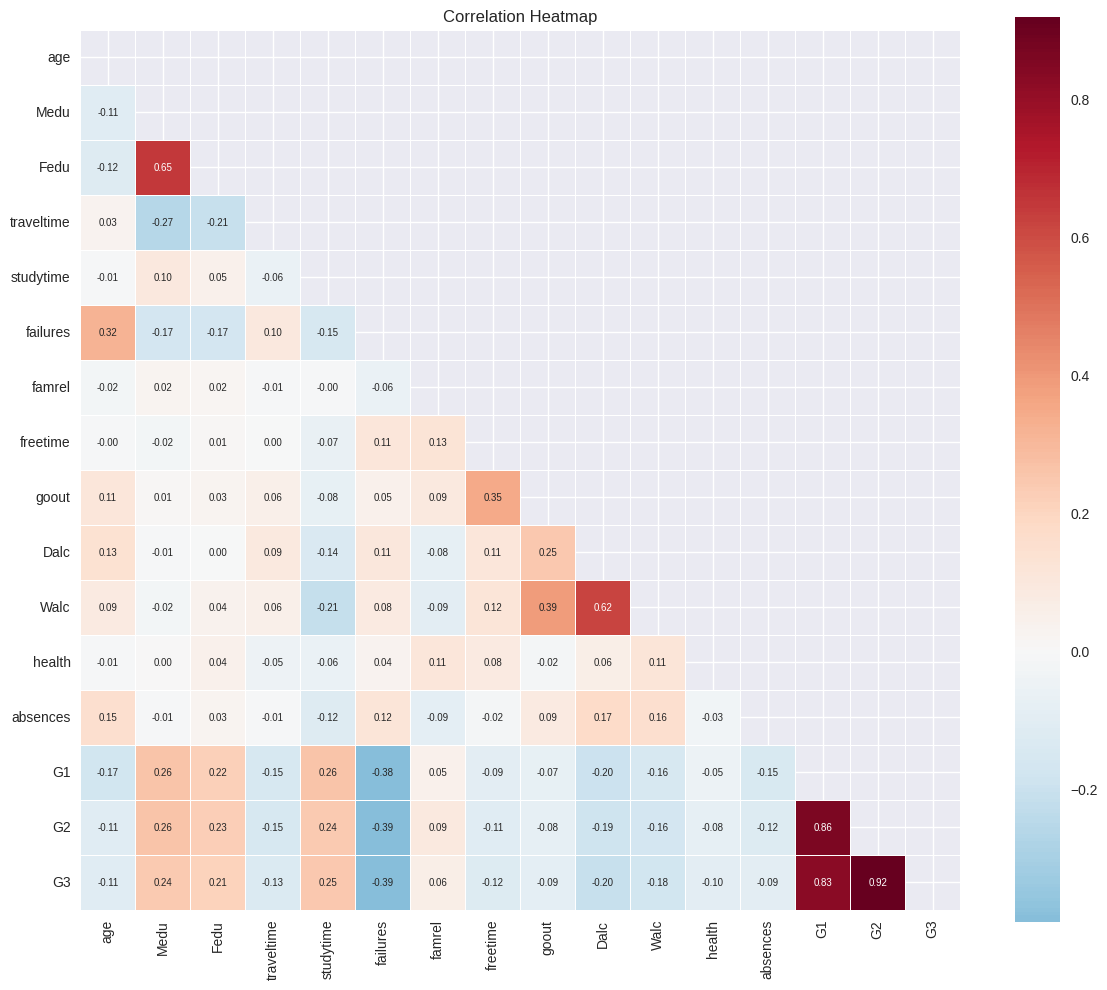

In [4]:
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, ax=ax, annot_kws={"size": 7})
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(figures_dir / "correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. Interactive Plots (Plotly)

An interactive scatter matrix of the grade progression and study habits,
plus a 3D scatter of `G1`, `G2`, `G3` colored by `sex`. These are saved
as standalone HTML files that can be opened directly in a browser.

In [5]:
scatter_cols = ["studytime", "absences", "G1", "G2", "G3"]
scatter_cols = [c for c in scatter_cols if c in df.columns]

fig = px.scatter_matrix(
    df,
    dimensions=scatter_cols,
    color="sex" if "sex" in df.columns else None,
    title="Scatter Matrix: Study Habits & Grades",
)
fig.write_html(figures_dir / "scatter_matrix.html")

fig3d = px.scatter_3d(
    df,
    x="G1", y="G2", z="G3",
    color="sex" if "sex" in df.columns else None,
    opacity=0.7, width=800, height=600,
    title="3D Scatter: G1 vs G2 vs G3",
)
fig3d.write_html(figures_dir / "3d_scatter.html")
fig3d.show()

## 5. Q-Q Plots for Normality

Visual check for normality on the grade columns and `absences`, paired
with Student B's Shapiro-Wilk p-values from `reports/normality_tests.csv`.

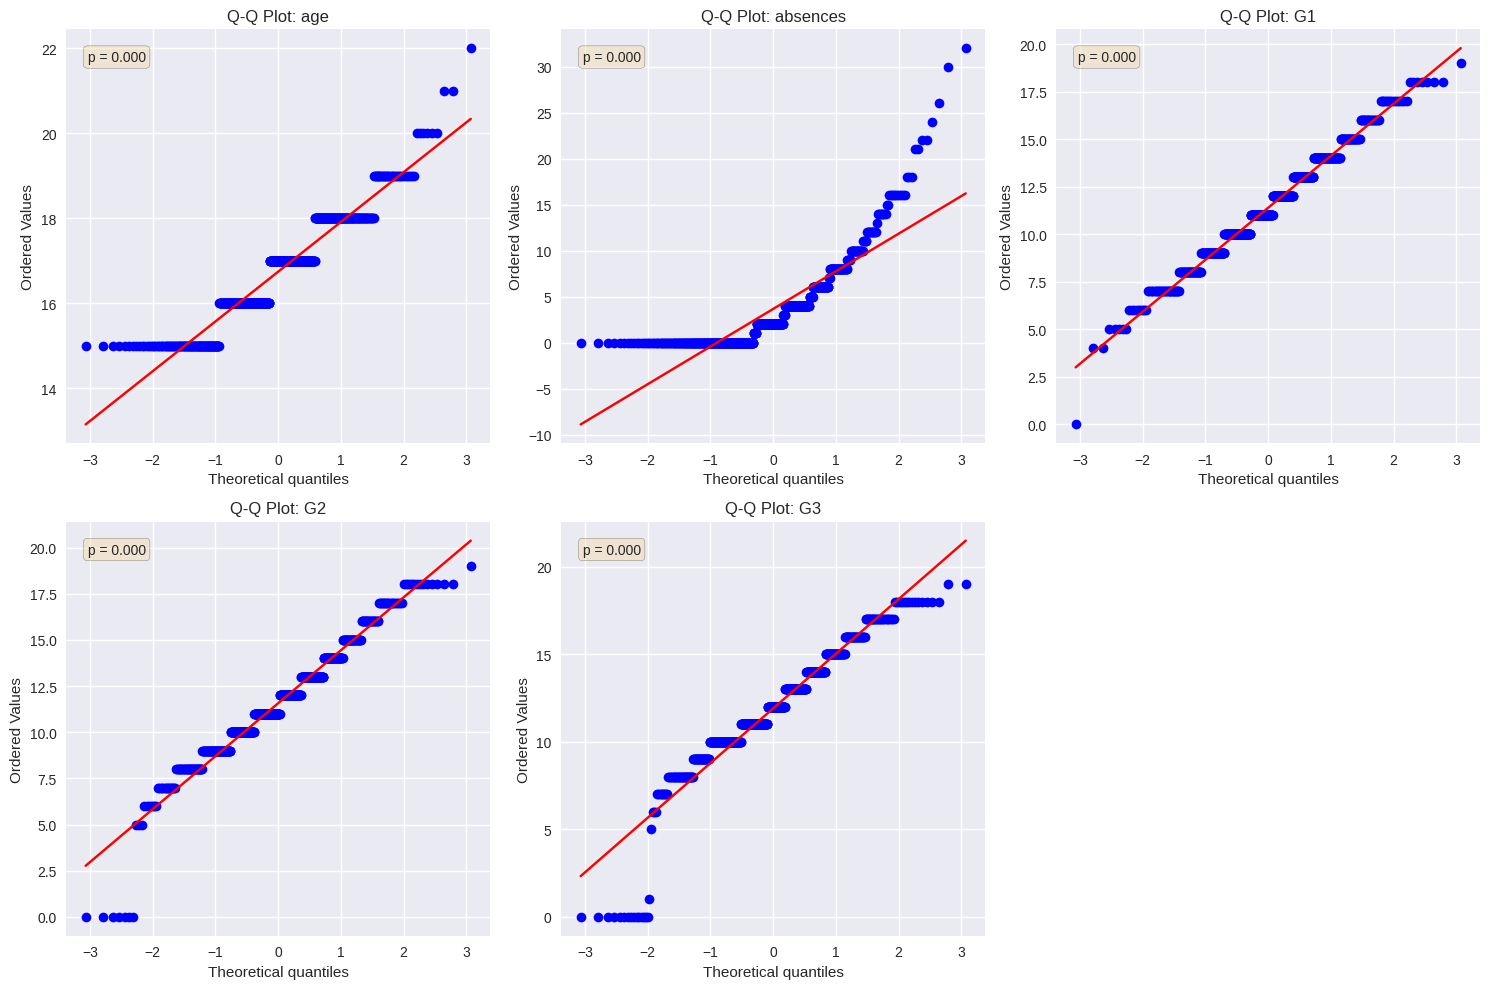

All visualizations saved to reports/figures/


In [6]:
qq_cols = ["age", "absences", "G1", "G2", "G3"]
qq_cols = [c for c in qq_cols if c in numeric_cols]

n_cols = 3
n_rows = (len(qq_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for idx, col in enumerate(qq_cols):
    data = df[col].dropna()
    stats.probplot(data, dist="norm", plot=axes[idx])
    axes[idx].set_title(f"Q-Q Plot: {col}")
    _, p_value = stats.shapiro(data)
    axes[idx].text(0.05, 0.95, f"p = {p_value:.3f}", transform=axes[idx].transAxes,
                   verticalalignment="top",
                   bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

for idx in range(len(qq_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig(figures_dir / "qq_plots.png", dpi=300, bbox_inches="tight")
plt.show()

print("All visualizations saved to reports/figures/")